# 07 — Sous-motifs par topic modeling, hors SARA

**Objectif** — reconstruire des sous-motifs à l'intérieur des catégories
déclarées **autres que SARA** (`ticket_type_name`), sans présupposer de
taxonomie, en complément du notebook 04.

**Pourquoi un périmètre complémentaire, pas le même périmètre.** Le notebook 04
applique une taxonomie conçue pour un problème précis — l'argent qui quitte
SARA sans arriver au bénéficiaire. Cette taxonomie n'a aucune raison de bien
décrire ce qui se passe sur COMPTE, CARTE ou BÉNÉFICIAIRE ERRONÉ : plutôt que
de forcer les mêmes six familles sur des catégories qu'elles ne visent pas, ce
notebook laisse le vocabulaire de **chaque catégorie hors SARA** former ses
propres groupes.

| | Notebook 04 — classification causale | Notebook 07 — topic modeling |
|---|---|---|
| Périmètre | tout le périmètre d'analyse (SARA inclus, 8 348 textes) | **complémentaire de SARA** (3 563 textes, 42,7 % de la base) |
| Taxonomie | conçue à la main, 6 familles, spécifique au problème SARA ↔ mobile money | aucune a priori : les mots qui reviennent ensemble forment les groupes, catégorie par catégorie |
| Couverture | plafonne à 57 % de rappel (43,0 % de reliquat, tout le périmètre) | ~98 % par construction sur son propre périmètre (NMF affecte toujours un ticket au topic le plus proche) |
| Auditabilité | ligne à ligne, une règle = un motif regex lisible | un topic n'a de sens qu'après lecture humaine de ses mots-clés |

Les deux notebooks partagent la même **base de départ** (périmètre d'analyse
causale, § 3.4 du protocole, `chargement.perimetre_analyse` + filtre de texte
exploitable) — seul le sous-ensemble modélisé diffère.

| | |
|---|---|
| **Entrée** | périmètre d'analyse défini au notebook 03, restreint à `ticket_type_name != "SARA"` |
| **Sorties** | `resultats/tables/07_topics_resume.csv` + 1 figure |
| **Suite** | notebook 06 — synthèse (à mettre à jour pour intégrer ces résultats) |

**Avertissement méthodologique.** Un topic n'est qu'un groupe de mots
statistiquement associés : il ne porte pas de sens tant qu'un humain ne l'a pas
lu. Les libellés proposés en section 3 sont une lecture, pas une vérité —
exactement la même réserve que l'audit manuel du notebook 04 (§ 4.5 du
protocole : jeu de référence annoté, double annotation, encore à réaliser).

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, texte, topics, viz

viz.appliquer_charte()
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 140)

df = chargement.typer(chargement.charger_brut())
messages = chargement.charger_messages_ouverture()
# perimetre_analyse applique la regle a la journee sur texte enrichi (CSV +
# message d'ouverture recupere dans conversations_.xlsx) et fournit deja
# "texte" / "a_texte" -- notebook 03, §3.4 du protocole.
analyse = chargement.perimetre_analyse(df, messages)
base = analyse[analyse["a_texte"]].copy()

# Périmètre de ce notebook : le complémentaire de SARA. La classification
# causale du notebook 04 reste le regard dédié sur SARA ; ce notebook explore
# le reste (COMPTE, BENEFICIAIRE ERRONE, CARTE...) sans lui imposer sa
# taxonomie.
hors_sara = base[base["ticket_type_name"] != "SARA"].copy()

# Le corpus vectorisé doit être masqué AVANT tout ajustement TF-IDF : un
# numéro de compte ou de téléphone peu fréquent deviendrait sinon un terme du
# vocabulaire et pourrait apparaître en clair dans une liste de mots-clés
# versionnée (§ 7.3 du protocole).
hors_sara["texte_masque"] = hors_sara["texte"].map(texte.masquer_identifiants)

print(f"Base d'analyse (notebook 04) : {len(base):,} tickets")
print(
    f"Périmètre de ce notebook — hors SARA : {len(hors_sara):,} tickets "
    f"({len(hors_sara) / len(base) * 100:.1f} % de la base)"
)

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Base d'analyse (notebook 04) : 8,348 tickets
Périmètre de ce notebook — hors SARA : 3,563 tickets (42.7 % de la base)


## 1. Répartition hors SARA, et catégories trop petites pour être modélisées

Un topic ajusté sur moins de `topics.TICKETS_MIN_CATEGORIE` tickets n'est que du
bruit statistique : la catégorie est alors laissée à `non_modelise` plutôt que
de produire un résultat qui a l'air valide mais ne l'est pas.

In [2]:
effectifs = hors_sara["ticket_type_name"].value_counts()
apercu = effectifs.to_frame("effectif")
apercu["pct_hors_sara"] = (apercu["effectif"] / len(hors_sara) * 100).round(1)
apercu["modelisee"] = apercu["effectif"] >= topics.TICKETS_MIN_CATEGORIE
apercu

,effectif,pct_hors_sara,modelisee
ticket_type_name,,,
COMPTE,2629,73.8,True
BENEFICIAIRE ERRONE,488,13.7,True
CARTE,150,4.2,True
ACCUEIL,103,2.9,True
CREDIT,80,2.2,True
OPERATIONS_INTERNATIONALES,42,1.2,True
DECOUVERT,27,0.8,False
CARTE_BLANCHE,20,0.6,False
EFIRST,17,0.5,False


## 2. Ajustement des topics, catégorie par catégorie

`topics.topics_par_categorie` ajuste un TF-IDF + NMF **indépendant par
catégorie** (§ topics.py) : le vocabulaire de COMPTE n'a aucune raison d'être
celui de CARTE, et les mélanger diluerait les deux. Le nombre de topics par
catégorie suit la règle empirique `n_tickets // 40`, bornée entre 2 et 8.

In [3]:
hors_sara["sous_motif"], resume_brut = topics.topics_par_categorie(
    hors_sara, colonne_texte="texte_masque", colonne_categorie="ticket_type_name"
)

couverture = (hors_sara["sous_motif"] != "non_modelise").mean() * 100
print(f"Couverture — tickets rattachés à un topic : {couverture:.1f} % du périmètre hors SARA\n")
resume_brut

Couverture — tickets rattachés à un topic : 97.8 % du périmètre hors SARA



,categorie,sous_motif,effectif,pct_categorie,mots_cles
0,ACCUEIL,ACCUEIL#0,77,74.8,"compte, sara, compte sara, arrive, sara money, connecter, reclamation, pourquoi, plus, depuis"
1,ACCUEIL,ACCUEIL#1,25,24.3,"money, account, sara, money account, orange, received, transaction, sara money, orange money, withdrawal"
2,ACCUEIL,ACCUEIL#non_modelise,1,1.0,(texte sans terme retenu par le vectoriseur)
3,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#3,79,16.2,"tel, lieu, numero tel, lieu tel, tel lieu, number, numero, sent, montant, wrong"
4,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#4,73,15.0,"transaction, erreur transaction, erreur, transaction erreur, annulation, fais erreur, fais, transaction fais, transaction sara, annulati..."
5,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#0,70,14.3,"money, orange, orange money, compte, sara, compte sara, vers orange, vers, sara money, compte orange"
6,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#7,69,14.1,"transfert, vers, transfert argent, autre, argent, vers autre, operateur, transfert vers, vers numero, numero"
7,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#2,66,13.5,"errone, beneficiaire errone, beneficiaire, numero errone, annulation transaction, annulation, errone erreur, transaction, numero, errone..."
8,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#1,59,12.1,"erreur beneficiaire, beneficiaire, erreur, beneficiaire envoye, envoye, numero, erreur erreur, numero beneficiaire, voulais, beneficiair..."
9,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#6,45,9.2,"destinataire, erreur destinataire, erreur, erreur numero, numero telephone, numero, telephone, fait erreur, destinataire erreur, fait"


## 3. Audit — donner un nom à chaque topic

Un mot-clé n'est pas une lecture. Avant d'attribuer un libellé, on relit un
échantillon de tickets masqués par topic — même logique que l'audit du reliquat
au notebook 04 (§ 4.5 du protocole). L'échantillon complet (3 tickets par
topic, graine fixe) part dans `data/audit/`, hors dépôt ; seuls les topics des
deux catégories qui pèsent le plus (COMPTE, BENEFICIAIRE ERRONE) sont montrés
ici à titre de justification.

In [4]:
GRAINE_AUDIT = 3  # même graine que texte.echantillon_non_classes (notebook 04)
N_PAR_TOPIC = 3

echantillons = (
    hors_sara[hors_sara["sous_motif"] != "non_modelise"]
    .groupby("sous_motif")["texte_masque"]
    .apply(lambda s: s.sample(min(N_PAR_TOPIC, len(s)), random_state=GRAINE_AUDIT))
    .reset_index(level=0)
    .rename(columns={"texte_masque": "texte"})
)
chargement.sauver_audit(echantillons, "07_audit_echantillons_topics")

for categorie in ["COMPTE", "BENEFICIAIRE ERRONE"]:
    print(f"\n=== {categorie} ===")
    for sous_motif in sorted(echantillons.loc[echantillons["sous_motif"].str.startswith(categorie), "sous_motif"].unique()):
        print(f"\n-- {sous_motif} --")
        for t in echantillons.loc[echantillons["sous_motif"] == sous_motif, "texte"]:
            print(" •", t[:130])

  -> data/audit/07_audit_echantillons_topics.csv  (hors dépôt, non versionné)

=== COMPTE ===

-- COMPTE#0 --
 • demande d'explication et de remboursement d'une somme qui m'a ete preleve. ce n'est pas la premiere fois qu'un prelevement soit fa
 • bonsoir !! 40 mille ont ete deduits de mon compte.veuillez me rembourser svp
 • reclamation d'un montant debite bonsoir

-- COMPTE#1 --
 • i did two transaction yesterday from my bank account to my momo. it showed that transaction failed. but checking my bank app now i
 • please i will like to log in into my sara account app using my email ( [EMAIL]) and not the phone number
 • i did two transaction today from my bank account to my momo. it showed that transaction failed. but checking my bank app now its s

-- COMPTE#2 --
 • jai fais un retrait ce matin via orange money jusqu'a present rien dans mon compte orange pourtant le compte bancaire est deja deb
 • en voulant retirer l'argent dans mon compte sara money pour orange money j'ai errone le 

## 4. Libellés — lecture manuelle des topics

Un libellé par topic, écrit après lecture des mots-clés **et** de l'échantillon
audité (section 3, et `data/audit/07_audit_echantillons_topics.csv` pour les
catégories non montrées ci-dessus). Ces libellés sont une **lecture
individuelle**, non revalidée par une seconde personne — la même réserve que
l'audit du notebook 04 (§ 4.5 du protocole, double annotation encore à
réaliser).

In [5]:
# Libellé écrit après lecture des mots-clés + échantillon audité (section 3).
# Modifier ce dictionnaire si les topics changent (nouvel export, seuils modifiés).
LIBELLES = {
    "COMPTE#0": "Débit contesté, demande de remboursement",
    "COMPTE#1": "Compte débité, argent non reçu (anglophone)",
    "COMPTE#2": "Transfert compte -> Orange Money non reçu",
    "COMPTE#3": "Transfert compte bancaire <-> SARA non arrivé",
    "COMPTE#4": "Demande de transfert non exécutée ou erreur de numéro",
    "COMPTE#5": "Salaire, solde ou retrait contesté (générique)",
    "COMPTE#6": "Compte épargne / courant : retrait ou retranchement contesté",
    "COMPTE#7": "Compte bancaire débité, transfert non abouti",
    "BENEFICIAIRE ERRONE#0": "Bénéficiaire erroné, transfert SARA -> Orange Money",
    "BENEFICIAIRE ERRONE#1": "Erreur de bénéficiaire lors de l'envoi",
    "BENEFICIAIRE ERRONE#2": "Bénéficiaire erroné, demande d'annulation de la transaction",
    "BENEFICIAIRE ERRONE#3": "Erreur de numéro (formulation courte, bilingue)",
    "BENEFICIAIRE ERRONE#4": "Erreur de transaction, demande d'annulation",
    "BENEFICIAIRE ERRONE#5": "Confusion sur le dernier chiffre du numéro bénéficiaire",
    "BENEFICIAIRE ERRONE#6": "Erreur de numéro du destinataire",
    "BENEFICIAIRE ERRONE#7": "Transfert envoyé vers un autre numéro/opérateur par erreur",
    "CARTE#0": "Retrait GAB débité, argent non obtenu",
    "CARTE#1": "Carte Visa/prépayée : demande ou dysfonctionnement",
    "CARTE#2": "Retrait GAB débité, argent non obtenu (anglophone)",
    "ACCUEIL#0": "Accès à SARA impossible ou argent non arrivé (formulation générique)",
    "ACCUEIL#1": "Argent non reçu (anglophone, générique)",
    "CREDIT#0": "Demande de crédit scolaire, sans suite",
    "CREDIT#1": "Loan requested, not disbursed (anglophone)",
    "OPERATIONS_INTERNATIONALES#0": "Transfert international, fonds non reçus",
    "OPERATIONS_INTERNATIONALES#1": "International transfer, funds not received (anglophone)",
}

resume = resume_brut.copy()
resume["libelle"] = resume["sous_motif"].map(LIBELLES).fillna(
    resume["sous_motif"].apply(lambda s: "Texte insuffisant après filtrage" if s.endswith("non_modelise") else "")
)
manquants = resume.loc[(resume["libelle"] == "") , "sous_motif"].tolist()
assert not manquants, f"Topics sans libellé : {manquants}"

chargement.sauver_table(resume, "07_topics_resume")
resume

  -> resultats/tables/07_topics_resume.csv


,categorie,sous_motif,effectif,pct_categorie,mots_cles,libelle
0,ACCUEIL,ACCUEIL#0,77,74.8,"compte, sara, compte sara, arrive, sara money, connecter, reclamation, pourquoi, plus, depuis",Accès à SARA impossible ou argent non arrivé (formulation générique)
1,ACCUEIL,ACCUEIL#1,25,24.3,"money, account, sara, money account, orange, received, transaction, sara money, orange money, withdrawal","Argent non reçu (anglophone, générique)"
2,ACCUEIL,ACCUEIL#non_modelise,1,1.0,(texte sans terme retenu par le vectoriseur),Texte insuffisant après filtrage
3,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#3,79,16.2,"tel, lieu, numero tel, lieu tel, tel lieu, number, numero, sent, montant, wrong","Erreur de numéro (formulation courte, bilingue)"
4,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#4,73,15.0,"transaction, erreur transaction, erreur, transaction erreur, annulation, fais erreur, fais, transaction fais, transaction sara, annulati...","Erreur de transaction, demande d'annulation"
5,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#0,70,14.3,"money, orange, orange money, compte, sara, compte sara, vers orange, vers, sara money, compte orange","Bénéficiaire erroné, transfert SARA -> Orange Money"
6,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#7,69,14.1,"transfert, vers, transfert argent, autre, argent, vers autre, operateur, transfert vers, vers numero, numero",Transfert envoyé vers un autre numéro/opérateur par erreur
7,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#2,66,13.5,"errone, beneficiaire errone, beneficiaire, numero errone, annulation transaction, annulation, errone erreur, transaction, numero, errone...","Bénéficiaire erroné, demande d'annulation de la transaction"
8,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#1,59,12.1,"erreur beneficiaire, beneficiaire, erreur, beneficiaire envoye, envoye, numero, erreur erreur, numero beneficiaire, voulais, beneficiair...",Erreur de bénéficiaire lors de l'envoi
9,BENEFICIAIRE ERRONE,BENEFICIAIRE ERRONE#6,45,9.2,"destinataire, erreur destinataire, erreur, erreur numero, numero telephone, numero, telephone, fait erreur, destinataire erreur, fait",Erreur de numéro du destinataire


## 5. Volumes — la catégorie qui pèse le plus hors SARA

  -> resultats/figures/07_topics_compte.png


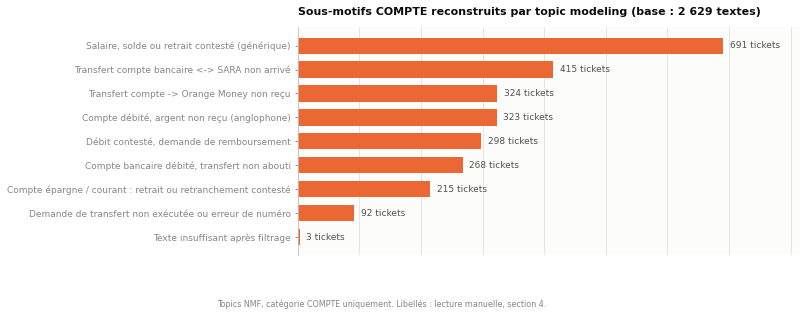

In [6]:
compte = resume[resume["categorie"] == "COMPTE"].set_index("libelle")["effectif"]

fig, ax = plt.subplots(figsize=(9, 4.2))
viz.barres_horizontales(
    compte,
    f"Sous-motifs COMPTE reconstruits par topic modeling (base : {int(compte.sum()):,} textes)".replace(",", " "),
    unite=" tickets",
    couleur=viz.SERIES[1],
    ax=ax,
    format_valeur="{:,.0f}",
)
viz.annoter_source(
    fig, "Topics NMF, catégorie COMPTE uniquement. Libellés : lecture manuelle, section 4."
)
viz.sauver(fig, "07_topics_compte")
plt.show()

## 6. Ce que le topic modeling apporte que les règles causales ne voient pas

Le notebook 04 applique ses six familles sur tout le périmètre, y compris hors
SARA — ce n'est pas qu'un rappel global insuffisant, c'est que la taxonomie
elle-même ne vise pas ces catégories. On le vérifie en croisant `famille`
(notebook 04) et `ticket_type_name`, sur les mêmes catégories que ce notebook.

In [7]:
base["famille"] = texte.classer(base["texte"])

comparaison = (
    base[base["ticket_type_name"] != "SARA"]
    .groupby("ticket_type_name")["famille"]
    .apply(lambda s: (s == texte.NON_CLASSE).mean() * 100)
    .rename("pct_non_classe_regles")
    .to_frame()
)
comparaison["pct_couvert_topics"] = comparaison.index.map(
    lambda cat: (hors_sara.loc[hors_sara["ticket_type_name"] == cat, "sous_motif"] != "non_modelise").mean() * 100
    if cat in hors_sara["ticket_type_name"].values
    else float("nan")
)
comparaison.round(1).sort_values("pct_non_classe_regles", ascending=False)

/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


,pct_non_classe_regles,pct_couvert_topics
ticket_type_name,,
MAC,85.7,0.0
CREDIT,75.0,100.0
DECOUVERT,74.1,0.0
ACCUEIL,58.3,99.0
COMPTE,53.3,99.9
OPERATIONS_INTERNATIONALES,42.9,92.9
EFIRST,41.2,0.0
BENEFICIAIRE ERRONE,40.6,99.6
CARTE,24.7,100.0


**Lecture du tableau.** Sur chaque catégorie hors SARA modélisée, le topic
modeling couvre 93 à 100 % des textes, contre un reliquat de règles causales de
24,7 % (CARTE) à 75,0 % (CREDIT) :

- **CREDIT** : 75,0 % non classés par les règles causales — attendu, la
  taxonomie du notebook 04 n'a jamais visé les demandes de crédit. Le topic
  modeling y révèle un sous-motif que rien d'autre ne montrait : **le crédit
  scolaire**, 85 % des tickets CREDIT (`CREDIT#0`).
- **BENEFICIAIRE ERRONE** : 40,6 % non classés par les règles, alors que
  c'est une catégorie **déclarée par le client au dépôt** comme étant déjà, par
  construction, une erreur de bénéficiaire. La règle `erreur_client` du
  notebook 04 ne capte donc que 59,4 % de ce qu'elle est censée capter. Les 8
  topics de cette catégorie confirment que la taxonomie n'est pas en cause
  (tous décrivent la même chose : numéro ou bénéficiaire confondu) — c'est bien
  un problème de **rappel des règles**, exactement le diagnostic déjà posé au
  notebook 04 sur son propre périmètre.
- **OPERATIONS_INTERNATIONALES** franchit cette fois le seuil de modélisation
  (42 tickets, contre 25 dans la version précédente de ce notebook) : 92,9 %
  de ses textes sont désormais rattachés à un topic, contre 42,9 % de reliquat
  pour les règles causales — qui, sans surprise, ne visent pas non plus les
  virements internationaux.
- **Quatre catégories restent hors de portée des deux méthodes** —
  MAC, DECOUVERT, EFIRST, CARTE_BLANCHE (71 tickets, 2,0 % du périmètre hors
  SARA) : sous le seuil de `topics.TICKETS_MIN_CATEGORIE` pour le topic
  modeling, et 20 à 86 % de reliquat pour les règles causales. Ni l'une ni
  l'autre méthode n'y est fiable au volume actuel.

## 7. Limites et suite

1. **Les libellés n'ont pas été validés par une deuxième personne.** Même
   réserve qu'au notebook 04 (§ 4.5 du protocole) : à intégrer au jeu de
   référence annoté prévu pour la classification causale, ou à traiter en
   parallèle sur un échantillon dédié aux topics.
2. **Le nombre de topics par catégorie est une règle empirique** (`n // 40`,
   bornée [2, 8]), pas un optimum mesuré (ex. score de cohérence). À affiner si
   ces sous-motifs doivent être cités comme chiffre définitif dans le mémoire.
3. **Certains topics restent impurs** (section 3) — `COMPTE#3` et `COMPTE#4`
   mélangent chacun deux ou trois thèmes proches mais distincts dans leur
   échantillon audité (ex. `COMPTE#3` : transfert SARA non arrivé **et** une
   réinitialisation de mot de passe sans rapport). Signal à ne pas ignorer,
   pas une erreur à corriger silencieusement : soit un vocabulaire trop
   proche entre deux motifs réels, soit un nombre de topics encore mal
   calibré pour cette catégorie (point 2).
4. **Ce notebook ne couvre pas SARA** — c'est le rôle du notebook 04. La
   synthèse (notebook 06) doit être mise à jour pour présenter les deux
   analyses comme complémentaires plutôt que concurrentes, et non plus comme
   si le notebook 04 couvrait seul l'ensemble du périmètre.